# Voice Command Fingerprinting — Independent Reproduction

**Paper**: *"I Can Hear Your Alexa: Voice Command Fingerprinting on Smart Home Speakers"*  
Kennedy et al., IEEE CNS 2019

**This notebook** reproduces all core attack experiments **independently** 
and extends with new models and evaluation metrics.

---

## Notebook Structure

1. Setup & Configuration  
2. Data Loading  
3. Exploratory Data Analysis (EDA)  
4. Feature Extraction  
5. Experiment 1 — Original Models (LL-Jaccard, LL-NB, VNG++, P-SVM)  
6. Semantic Evaluation (Cosine Distance + Normalized Distance)  
7. Experiment 2 — New Traditional ML Models  
8. Experiment 3 — Deep Learning Models (1D-CNN, LSTM)  
9. Results Comparison Table  
10. Discussion & Export

---
## 1. Setup & Configuration

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import config
from src.utils import seed_everything, ensure_results_dirs

# Global seed
seed_everything(config.RANDOM_SEED)
ensure_results_dirs()

print(f'Random seed     : {config.RANDOM_SEED}')
print(f'CV folds        : {config.N_FOLDS}')
print(f'Dataset dir     : {config.TRACE_CSV_DIR}')
print(f'Results dir     : {config.RESULTS_DIR}')
print(f'Semantic method : {config.SEMANTIC_STRATEGY}')

Random seed     : 42
CV folds        : 5
Dataset dir     : /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/data/trace_csv
Results dir     : /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results
Semantic method : sentence_transformers


---
## 2. Data Loading

In [2]:
from src.data_loader import load_dataset, invert_label_map, load_trace, get_all_command_strings

filepaths, labels, label_map = load_dataset()
inv_label_map = invert_label_map(label_map)
all_commands  = get_all_command_strings(label_map)

labels_arr = np.array(labels)

print(f'Total samples : {len(filepaths)}')
print(f'Unique classes: {len(label_map)}')
print(f'Label examples: {dict(list(label_map.items())[:4])}')

# Quick verify: load one trace
sample_df = load_trace(filepaths[0])
print(f'\nSample trace   : {os.path.basename(filepaths[0])}')
sample_df.head()

Total samples : 1000
Unique classes: 100
Label examples: {'alexa': 0, 'do_dogs_dream': 1, 'do_you_like_cats_or_dogs': 2, 'flip_a_coin': 3}

Sample trace   : alexa_5_30s_L_1.csv


,time,size,direction
0,0.000000,176.0,1
1,0.000570,1500.0,1
2,0.000602,1500.0,1
3,0.000625,1163.0,1
4,0.005253,118.0,1


---
## 3. Exploratory Data Analysis

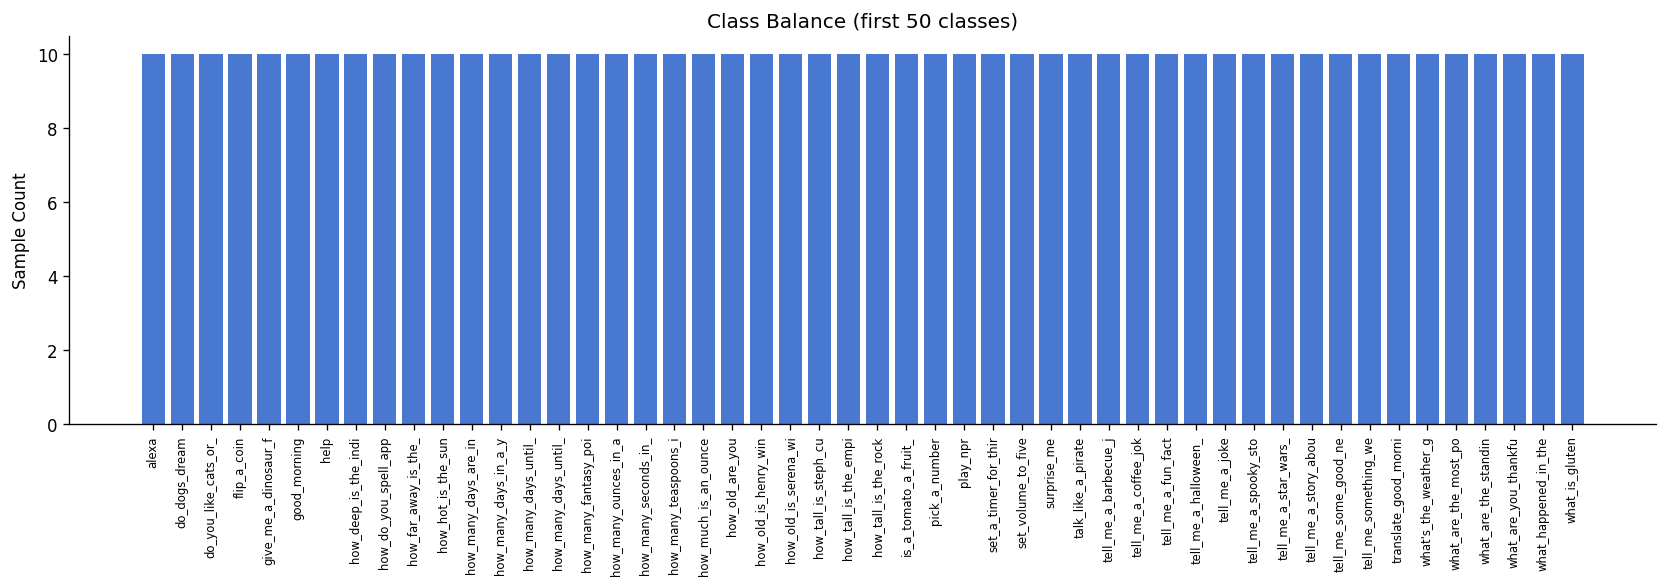

Samples per class — Min: 10, Max: 10, Mean: 10.0


In [3]:
# ── 3.1 Class Balance ─────────────────────────────────────────────────────
from src.utils import plot_class_balance

label_counts = Counter({inv_label_map[i]: cnt for i, cnt in Counter(labels).items()})
fig = plot_class_balance(label_counts, save_path=config.FIGURES_DIR / 'class_balance.png')
plt.show()

print(f'Samples per class — Min: {min(label_counts.values())}, '
      f'Max: {max(label_counts.values())}, '
      f'Mean: {np.mean(list(label_counts.values())):.1f}')

In [4]:
# ── 3.2-3.7 Bulk Trace Statistics ───────────────────────────────────────
from src.utils import (
    plot_trace_length_distribution,
    plot_packet_size_distribution,
    plot_upstream_downstream_scatter,
    plot_burst_distribution,
    plot_trace_duration_distribution,
)
from src.feature_extraction import _compute_bursts

trace_lengths, sizes_up, sizes_down = [], [], []
up_bytes_all, down_bytes_all, durations = [], [], []
all_burst_sizes, all_burst_counts = [], []

print('Collecting statistics from all traces...')
for fp in tqdm(filepaths):
    df = load_trace(fp)
    if df.empty:
        continue
    trace_lengths.append(len(df))
    sizes_up.extend(df.loc[df['direction'] == 1, 'size'].tolist())
    sizes_down.extend(df.loc[df['direction'] == -1, 'size'].tolist())
    up_bytes_all.append(df.loc[df['direction'] == 1, 'size'].sum())
    down_bytes_all.append(df.loc[df['direction'] == -1, 'size'].sum())
    durations.append(df['time'].max() - df['time'].min())
    bursts = _compute_bursts(df)
    all_burst_sizes.extend(bursts)
    all_burst_counts.append(len(bursts))

print('Done.')

  0%|          | 0/1000 [00:00<?, ?it/s]

Done.


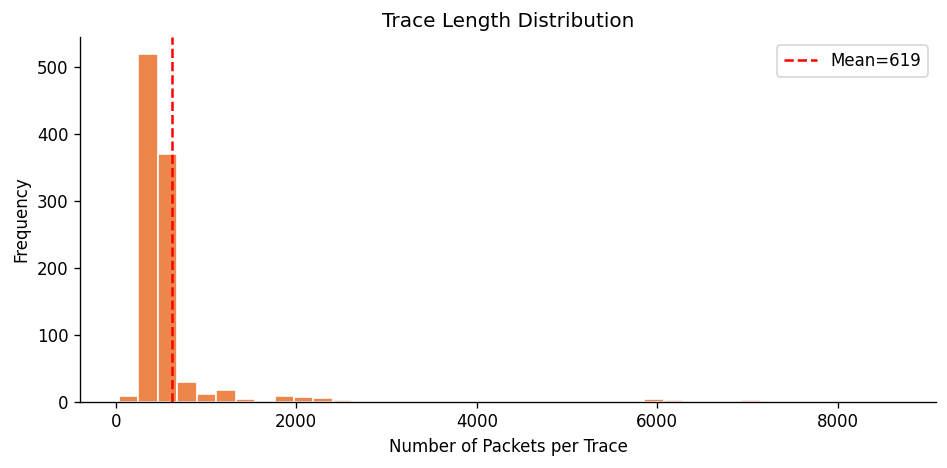

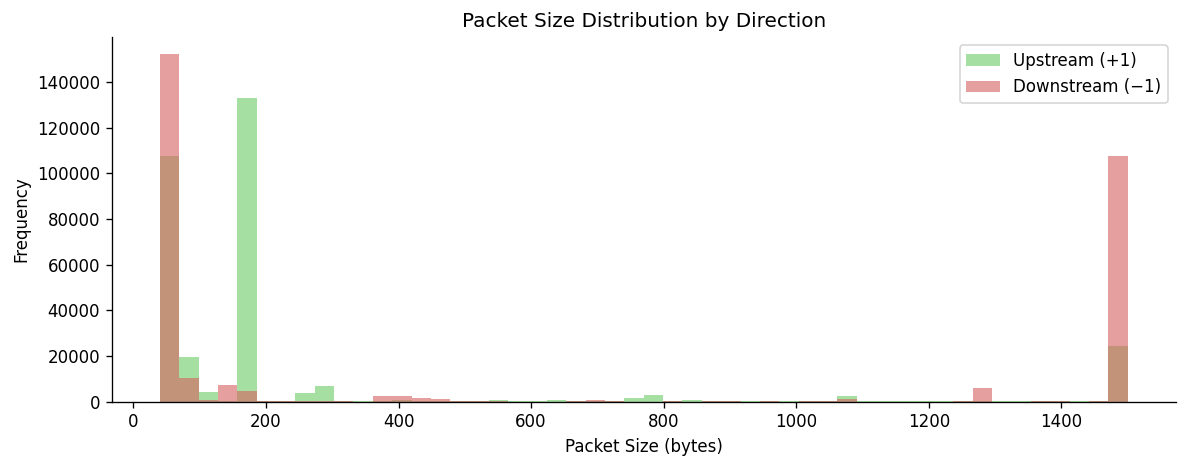

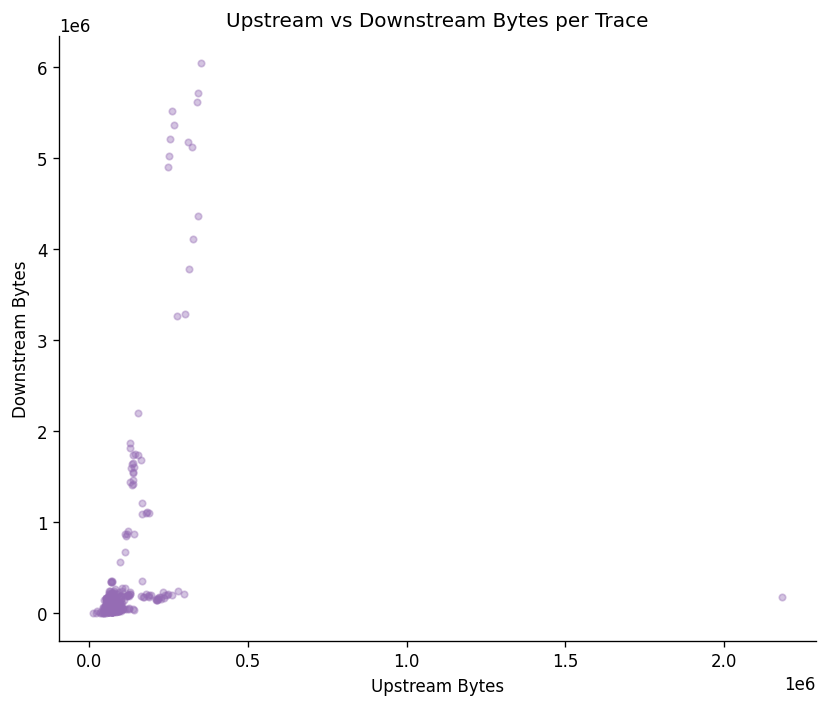

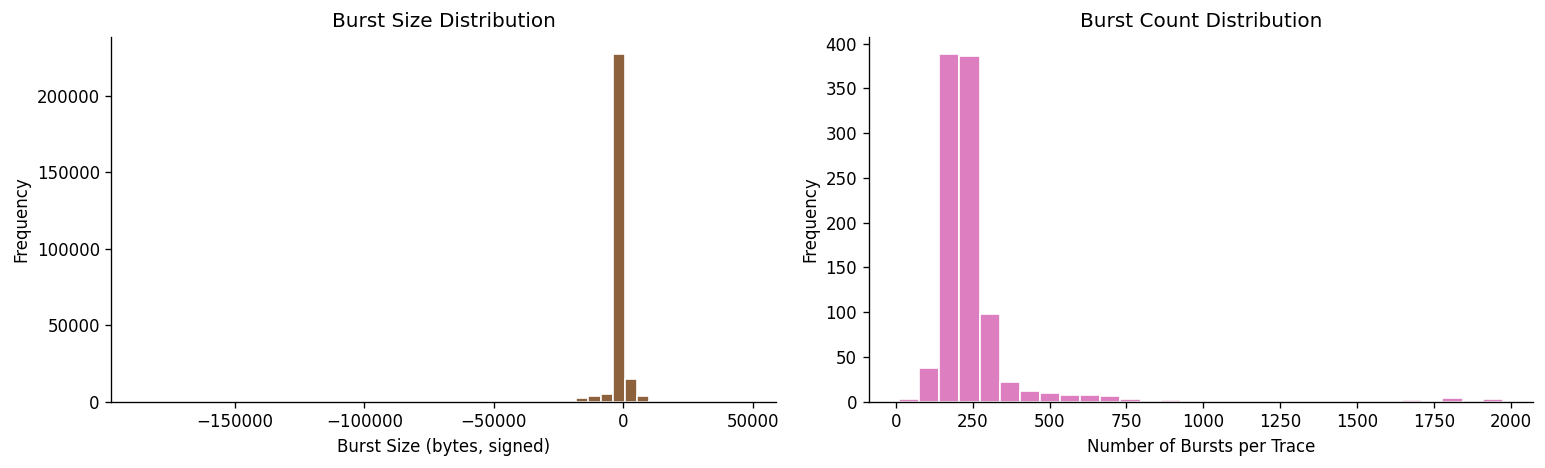

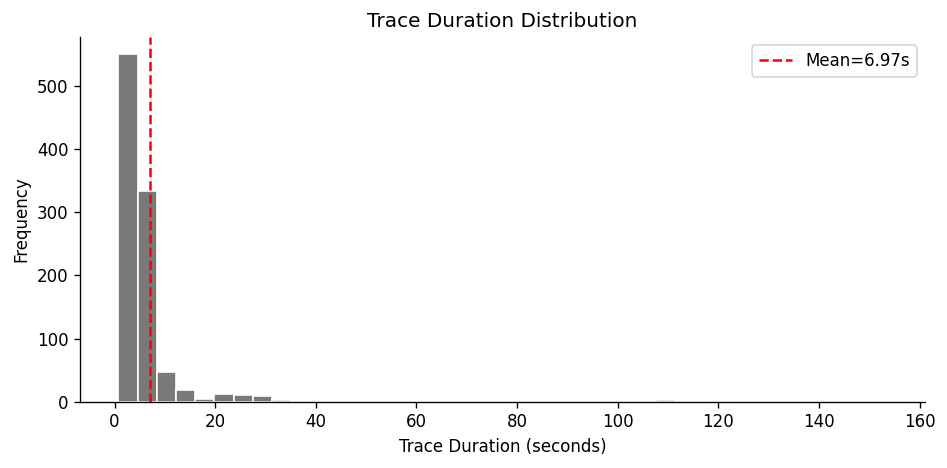

In [5]:
# Plot all EDA figures
fig = plot_trace_length_distribution(trace_lengths, save_path=config.FIGURES_DIR / 'trace_length_dist.png')
plt.show()

fig = plot_packet_size_distribution(sizes_up, sizes_down, save_path=config.FIGURES_DIR / 'packet_size_dist.png')
plt.show()

fig = plot_upstream_downstream_scatter(up_bytes_all, down_bytes_all, save_path=config.FIGURES_DIR / 'up_down_scatter.png')
plt.show()

fig = plot_burst_distribution(all_burst_sizes, all_burst_counts, save_path=config.FIGURES_DIR / 'burst_distribution.png')
plt.show()

fig = plot_trace_duration_distribution(durations, save_path=config.FIGURES_DIR / 'trace_duration_dist.png')
plt.show()

In [6]:
# ── 3.9 Statistical Summary Table ────────────────────────────────────────
eda_summary = pd.DataFrame({
    'Metric': [
        'Num Samples', 'Num Classes', 'Samples / Class (avg)',
        'Packets / Trace (mean)', 'Packets / Trace (std)',
        'Packets / Trace (min)', 'Packets / Trace (max)',
        'Trace Duration (mean, s)', 'Upstream Bytes (mean)',
        'Downstream Bytes (mean)', 'Bursts / Trace (mean)',
    ],
    'Value': [
        len(filepaths), len(label_map), len(filepaths)/len(label_map),
        np.mean(trace_lengths), np.std(trace_lengths),
        np.min(trace_lengths), np.max(trace_lengths),
        np.mean(durations),
        np.mean(up_bytes_all), np.mean(down_bytes_all),
        np.mean(all_burst_counts),
    ]
})
eda_summary['Value'] = eda_summary['Value'].apply(lambda x: f'{x:.2f}')
eda_summary.to_csv(config.TABLES_DIR / 'eda_summary.csv', index=False)
eda_summary

,Metric,Value
0,Num Samples,1000.00
1,Num Classes,100.00
2,Samples / Class (avg),10.00
3,Packets / Trace (mean),618.87
4,Packets / Trace (std),797.25
5,Packets / Trace (min),34.00
6,Packets / Trace (max),8658.00
7,"Trace Duration (mean, s)",6.97
8,Upstream Bytes (mean),81314.66
9,Downstream Bytes (mean),186310.54


---
## 4. Feature Extraction Demo

In [7]:
from src.feature_extraction import (
    compute_llnb_feature, compute_vngpp_feature, compute_psvm_feature, compute_jaccard_set
)

sample_fp = filepaths[0]
print(f'Sample file: {os.path.basename(sample_fp)}\n')

llnb_feat  = compute_llnb_feature(sample_fp)
vngpp_feat = compute_vngpp_feature(sample_fp)
psvm_feat  = compute_psvm_feature(sample_fp)
jacc_set   = compute_jaccard_set(sample_fp)

print(f'LL-NB  feature dim: {llnb_feat.shape[0]:>5}  | non-zero bins: {np.count_nonzero(llnb_feat)}')
print(f'VNG++  feature dim: {vngpp_feat.shape[0]:>5}  | non-zero bins: {np.count_nonzero(vngpp_feat)}')
print(f'P-SVM  feature dim: {psvm_feat.shape[0]:>5}  | non-zero bins: {np.count_nonzero(psvm_feat)}')
print(f'Jaccard set size  : {len(jacc_set):>5}  | sample elements: {list(jacc_set)[:5]}')

Sample file: alexa_5_30s_L_1.csv

LL-NB  feature dim:    31  | non-zero bins: 14
VNG++  feature dim:   164  | non-zero bins: 5
P-SVM  feature dim:   166  | non-zero bins: 7
Jaccard set size  :    36  | sample elements: [394, 1163, -113, 272, 273]


In [8]:
# ── Compute full feature matrices (cached for experiments) ────────────────
from src.feature_extraction import compute_features_batch

print('Computing LL-NB features...')
X_llnb  = compute_features_batch(filepaths, method='llnb')
print(f'  X_llnb  shape: {X_llnb.shape}')

print('Computing VNG++ features...')
X_vngpp = compute_features_batch(filepaths, method='vngpp')
print(f'  X_vngpp shape: {X_vngpp.shape}')

print('Computing P-SVM features...')
X_psvm  = compute_features_batch(filepaths, method='psvm')
print(f'  X_psvm  shape: {X_psvm.shape}')

Computing LL-NB features...
  X_llnb  shape: (1000, 31)
Computing VNG++ features...
  X_vngpp shape: (1000, 164)
Computing P-SVM features...
  X_psvm  shape: (1000, 166)


---
## 5. Experiment 1 — Original Paper Models

In [9]:
from src.training import cross_validate_sklearn, cross_validate_jaccard
from src.models import (
    make_llnb_model, make_vngpp_model,
    make_psvm_adaboost_model, make_psvm_svc_model,
)

exp1_cv_results = {}

# 1. LL-Jaccard
print('Running LL-Jaccard...')
exp1_cv_results['LL-Jaccard'] = cross_validate_jaccard(filepaths, labels_arr)
print(f"  Mean Acc: {exp1_cv_results['LL-Jaccard']['mean_accuracy']:.4f}")

# 2. LL-NB
print('Running LL-NB...')
exp1_cv_results['LL-NB'] = cross_validate_sklearn(make_llnb_model, X_llnb, labels_arr)
print(f"  Mean Acc: {exp1_cv_results['LL-NB']['mean_accuracy']:.4f}")

# 3. VNG++
print('Running VNG++...')
exp1_cv_results['VNG++'] = cross_validate_sklearn(make_vngpp_model, X_vngpp, labels_arr)
print(f"  Mean Acc: {exp1_cv_results['VNG++']['mean_accuracy']:.4f}")

# 4. P-SVM (AdaBoost) — paper's actual implementation
print('Running P-SVM (AdaBoost)...')
exp1_cv_results['P-SVM (AdaBoost)'] = cross_validate_sklearn(make_psvm_adaboost_model, X_psvm, labels_arr)
print(f"  Mean Acc: {exp1_cv_results['P-SVM (AdaBoost)']['mean_accuracy']:.4f}")

# 5. P-SVM (SVM) — original intent, tuned
print('Running P-SVM (SVM)...')
exp1_cv_results['P-SVM (SVM)'] = cross_validate_sklearn(make_psvm_svc_model, X_psvm, labels_arr)
print(f"  Mean Acc: {exp1_cv_results['P-SVM (SVM)']['mean_accuracy']:.4f}")

Running LL-Jaccard...
  Mean Acc: 0.1760
Running LL-NB...
  Mean Acc: 0.3000
Running VNG++...
  Mean Acc: 0.2400
Running P-SVM (AdaBoost)...
  Mean Acc: 0.0440
Running P-SVM (SVM)...
  Mean Acc: 0.1040


---
## 6. Semantic Evaluation

In [10]:
from src.semantic import get_semantic_vectors
from src.evaluation import compute_semantic_metrics_for_cv

# Build semantic vectors for all 100 voice command strings
print(f'Building semantic vectors using strategy: {config.SEMANTIC_STRATEGY}')
vec_dict = get_semantic_vectors(all_commands, strategy=config.SEMANTIC_STRATEGY)
print(f'Vectors built for {len(vec_dict)} commands. Vector dim: {len(next(iter(vec_dict.values())))}')

Building semantic vectors using strategy: sentence_transformers
[semantic] Loading sentence transformer: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[semantic] Encoding 100 voice commands...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

[semantic] Saved 100 vectors to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/semantic_vectors/command_vectors.pkl
Vectors built for 100 commands. Vector dim: 384


In [11]:
# Compute semantic metrics for Experiment 1
print('\n{:<25} {:>12} {:>18}'.format('Model', 'Mean SD', 'Mean NormDist'))
print('-' * 58)

exp1_semantic = {}
for model_name, cv_res in exp1_cv_results.items():
    mean_sd, mean_nd = compute_semantic_metrics_for_cv(
        cv_res['all_true'], cv_res['all_pred'], inv_label_map, vec_dict
    )
    exp1_semantic[model_name] = {'semantic_distance': mean_sd, 'normalized_semantic_distance': mean_nd}
    print(f'{model_name:<25} {mean_sd:>12.4f} {mean_nd:>18.2f}')

print(f'{"Random Guess (expected)":<25} {"N/A":>12} {49.5:>18.2f}')


Model                          Mean SD      Mean NormDist
----------------------------------------------------------
LL-Jaccard                      0.2490              38.37
LL-NB                           0.3586              32.05
VNG++                           0.3136              33.62
P-SVM (AdaBoost)                0.1229              46.83
P-SVM (SVM)                     0.1869              41.10
Random Guess (expected)            N/A              49.50


---
## 7. Experiment 2 — New Traditional ML Models

In [12]:
from src.models import (
    make_random_forest_model, make_xgboost_model,
    make_knn_model, make_logistic_regression_model,
)

# All new traditional models use P-SVM features (richest feature set)
exp2_cv_results = {}

print('Running Random Forest...')
exp2_cv_results['Random Forest'] = cross_validate_sklearn(make_random_forest_model, X_psvm, labels_arr)
print(f"  Mean Acc: {exp2_cv_results['Random Forest']['mean_accuracy']:.4f}")

print('Running XGBoost...')
try:
    exp2_cv_results['XGBoost'] = cross_validate_sklearn(make_xgboost_model, X_psvm, labels_arr)
    print(f"  Mean Acc: {exp2_cv_results['XGBoost']['mean_accuracy']:.4f}")
except ImportError as e:
    print(f'  Skipped: {e}')

print('Running KNN...')
exp2_cv_results['KNN (k=5)'] = cross_validate_sklearn(make_knn_model, X_psvm, labels_arr)
print(f"  Mean Acc: {exp2_cv_results['KNN (k=5)']['mean_accuracy']:.4f}")

print('Running Logistic Regression...')
exp2_cv_results['Logistic Regression'] = cross_validate_sklearn(make_logistic_regression_model, X_psvm, labels_arr)
print(f"  Mean Acc: {exp2_cv_results['Logistic Regression']['mean_accuracy']:.4f}")

Running Random Forest...
  Mean Acc: 0.2550
Running XGBoost...
  Mean Acc: 0.2940
Running KNN...
  Mean Acc: 0.3080
Running Logistic Regression...
  Mean Acc: 0.1070


In [ ]:
# Semantic metrics for new models
exp2_semantic = {}
for model_name, cv_res in exp2_cv_results.items():
    mean_sd, mean_nd = compute_semantic_metrics_for_cv(
        cv_res['all_true'], cv_res['all_pred'], inv_label_map, vec_dict
    )
    exp2_semantic[model_name] = {'semantic_distance': mean_sd, 'normalized_semantic_distance': mean_nd}


In [14]:
exp2_semantic

{'Random Forest': {'semantic_distance': 0.32572012963157615,
  'normalized_semantic_distance': 34.328},
 'XGBoost': {'semantic_distance': 0.358198517703393,
  'normalized_semantic_distance': 32.649},
 'KNN (k=5)': {'semantic_distance': 0.36650096288993517,
  'normalized_semantic_distance': 32.085},
 'Logistic Regression': {'semantic_distance': 0.1908111288943328,
  'normalized_semantic_distance': 41.49}}

---
## 8. Experiment 3 — Deep Learning Models

In [15]:
from src.training import cross_validate_dl
from src.models import Conv1DModel, LSTMModel

n_classes = len(label_map)
exp3_cv_results = {}

print('Running 1D-CNN...')
exp3_cv_results['1D-CNN'] = cross_validate_dl(
    model_factory=lambda nc: Conv1DModel(nc),
    filepaths=filepaths,
    y=labels_arr,
)
print(f"  Mean Acc: {exp3_cv_results['1D-CNN']['mean_accuracy']:.4f}")

print('Running LSTM...')
exp3_cv_results['LSTM'] = cross_validate_dl(
    model_factory=lambda nc: LSTMModel(nc, use_gru=False),
    filepaths=filepaths,
    y=labels_arr,
)
print(f"  Mean Acc: {exp3_cv_results['LSTM']['mean_accuracy']:.4f}")

print('Running GRU...')
exp3_cv_results['GRU'] = cross_validate_dl(
    model_factory=lambda nc: LSTMModel(nc, use_gru=True),
    filepaths=filepaths,
    y=labels_arr,
)
print(f"  Mean Acc: {exp3_cv_results['GRU']['mean_accuracy']:.4f}")

Running 1D-CNN...
[training] Loading sequence tensors for DL training...
  [DL Fold 1/5] acc=0.1900
  [DL Fold 2/5] acc=0.2100
  [DL Fold 3/5] acc=0.1550
  [DL Fold 4/5] acc=0.1650
  [DL Fold 5/5] acc=0.1450
  Mean Acc: 0.1730
Running LSTM...
[training] Loading sequence tensors for DL training...
  [DL Fold 1/5] acc=0.0300
  [DL Fold 2/5] acc=0.0150
  [DL Fold 3/5] acc=0.0050
  [DL Fold 4/5] 

KeyboardInterrupt: 

In [16]:
# Semantic metrics for DL models
exp3_semantic = {}
for model_name, cv_res in exp3_cv_results.items():
    mean_sd, mean_nd = compute_semantic_metrics_for_cv(
        cv_res['all_true'], cv_res['all_pred'], inv_label_map, vec_dict
    )
    exp3_semantic[model_name] = {'semantic_distance': mean_sd, 'normalized_semantic_distance': mean_nd}

In [17]:
exp3_semantic

{'1D-CNN': {'semantic_distance': 0.25213292314360297,
  'normalized_semantic_distance': 37.109}}

---
## 9. Results Comparison

In [18]:
from src.evaluation import (
    full_evaluation, build_results_dataframe,
    add_paper_reference_rows, save_results_csv, print_summary_table,
)
from src.utils import plot_model_comparison, plot_norm_dist_comparison, plot_confusion_matrix

all_eval = []

# Merge CV results with semantic metrics
def merge_and_evaluate(cv_dict, semantic_dict, group_label):
    results = []
    for name, cv_res in cv_dict.items():
        sem = semantic_dict.get(name, {})
        # Inject semantic metrics into cv_res for full_evaluation
        ev = full_evaluation(name, cv_res, inv_label_map, vec_dict)
        results.append(ev)
    return results

all_eval += merge_and_evaluate(exp1_cv_results, exp1_semantic, 'original')
all_eval += merge_and_evaluate(exp2_cv_results, exp2_semantic, 'new_ml')
all_eval += merge_and_evaluate(exp3_cv_results, exp3_semantic, 'dl')

# Build comparison dataframe
df_results = build_results_dataframe(all_eval)
df_with_paper = add_paper_reference_rows(df_results)

print_summary_table(df_with_paper)


                   Model  Accuracy  Acc Std     F1  Semantic Dist  Norm Sem Dist
              LL-Jaccard     0.176   0.0213 0.1845         0.2490         38.371
                   LL-NB     0.300   0.0279 0.2891         0.3586         32.049
                   VNG++     0.240   0.0251 0.2129         0.3136         33.619
        P-SVM (AdaBoost)     0.044   0.0107 0.0189         0.1229         46.831
             P-SVM (SVM)     0.104   0.0080 0.0889         0.1869         41.104
           Random Forest     0.255   0.0245 0.2428         0.3257         34.328
                 XGBoost     0.294   0.0143 0.2909         0.3582         32.649
               KNN (k=5)     0.308   0.0280 0.2862         0.3665         32.085
     Logistic Regression     0.107   0.0051 0.0868         0.1908         41.490
                  1D-CNN     0.173   0.0238 0.1585         0.2521         37.109
      LL-Jaccard [PAPER]     0.174      NaN    NaN         0.9490         46.990
           LL-NB [PAPER]   

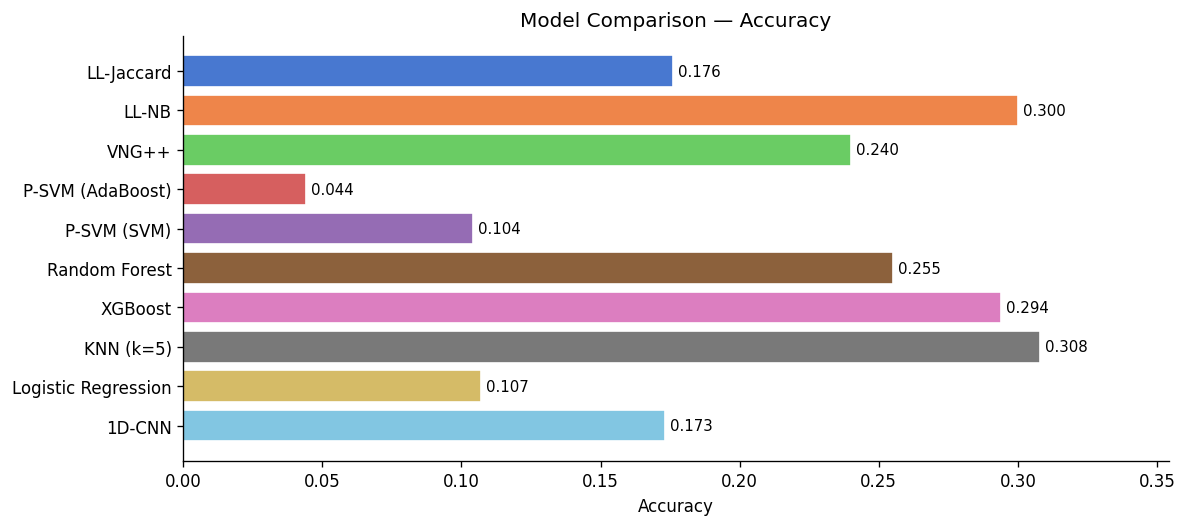

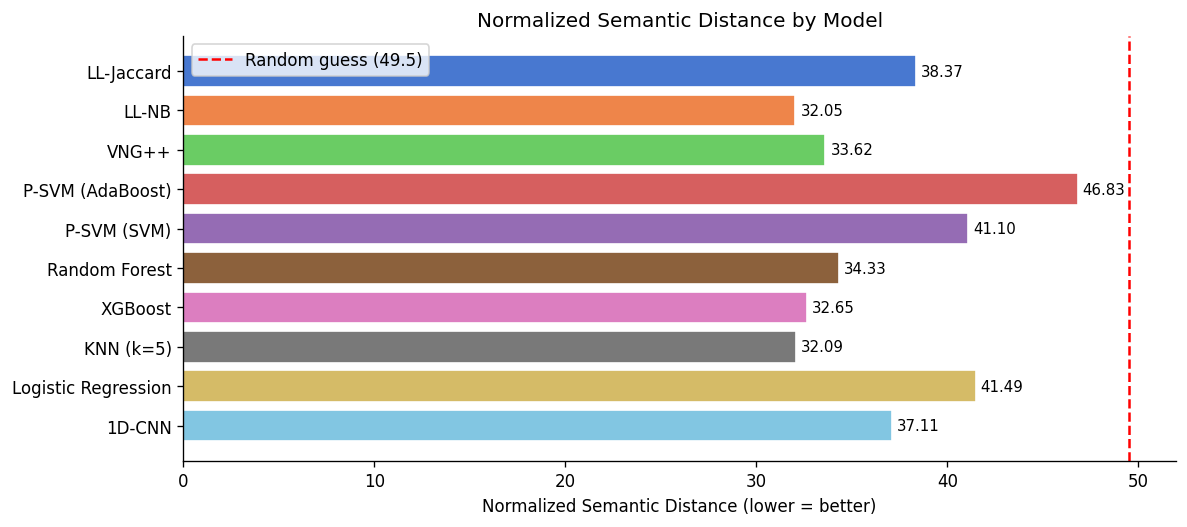

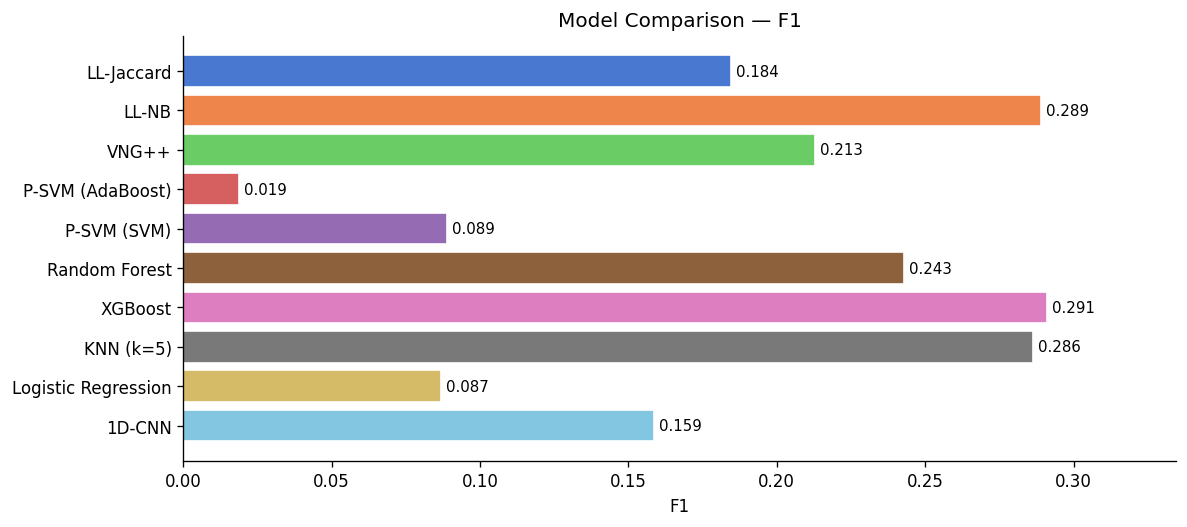

In [19]:
# ── Accuracy Comparison Plot ──────────────────────────────────────────────
fig = plot_model_comparison(df_results, metric='Accuracy',
                             save_path=config.FIGURES_DIR / 'model_comparison_accuracy.png')
plt.show()

# ── Normalized Semantic Distance Plot ─────────────────────────────────────
fig = plot_norm_dist_comparison(df_results,
                                 save_path=config.FIGURES_DIR / 'model_comparison_norm_dist.png')
plt.show()

# ── F1 Score Comparison ───────────────────────────────────────────────────
fig = plot_model_comparison(df_results, metric='F1',
                             save_path=config.FIGURES_DIR / 'model_comparison_f1.png')
plt.show()

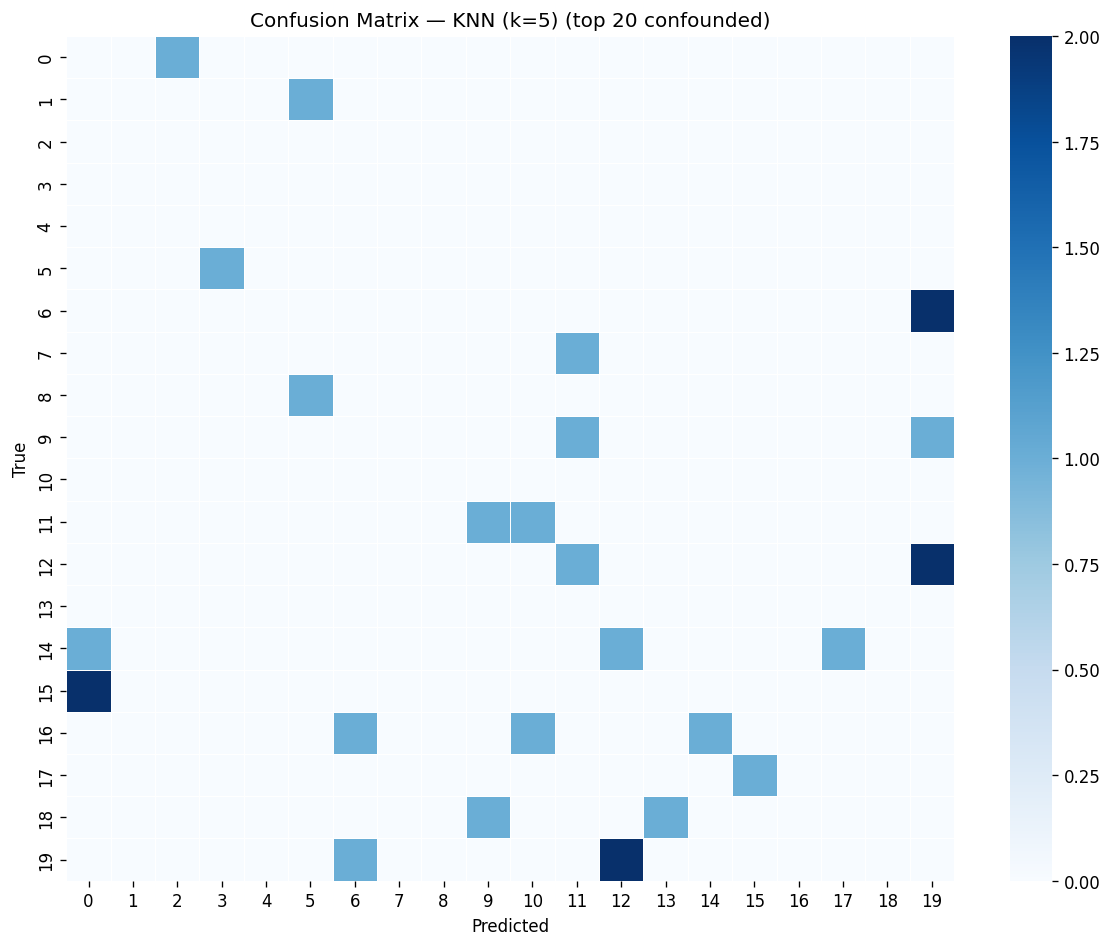

Best model: KNN (k=5)


In [20]:
# ── Confusion Matrix (best model) ─────────────────────────────────────────
best_model_name = df_results.loc[df_results['Accuracy'].idxmax(), 'Model']
best_eval = next(e for e in all_eval if e['model_name'] == best_model_name)

fig = plot_confusion_matrix(
    best_eval['confusion_matrix'],
    model_name=best_model_name,
    max_classes=20,
    save_path=config.FIGURES_DIR / f'confusion_matrix_{best_model_name.replace(" ", "_").replace("/","-")}.png',
)
plt.show()

print(f'Best model: {best_model_name}')

---
## 10. Discussion & Export

In [21]:
# Split and save per-group result tables
original_names = list(exp1_cv_results.keys())
new_ml_names   = list(exp2_cv_results.keys())
dl_names       = list(exp3_cv_results.keys())

save_results_csv(df_results[df_results['Model'].isin(original_names)],   'original_models.csv')
save_results_csv(df_results[df_results['Model'].isin(new_ml_names)],     'new_ml_models.csv')
save_results_csv(df_results[df_results['Model'].isin(dl_names)],         'dl_models.csv')
save_results_csv(df_results,                                               'comparison_all.csv')
save_results_csv(df_with_paper,                                            'paper_vs_repro.csv')

print('All result tables exported.')

[evaluation] Results saved to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/tables/original_models.csv
[evaluation] Results saved to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/tables/new_ml_models.csv
[evaluation] Results saved to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/tables/dl_models.csv
[evaluation] Results saved to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/tables/comparison_all.csv
[evaluation] Results saved to /home/umair/Documents/temp-s/python/VCFingerprinting/vcfp_reproduction/results/tables/paper_vs_repro.csv
All result tables exported.


In [22]:
# ── Discussion highlights ─────────────────────────────────────────────────
print('=== Reproduction Summary ===')
print(df_with_paper[['Model', 'Accuracy', 'F1', 'Norm Sem Dist']].to_string(index=False))

print('\n=== Key Observations ===')
repro_llnb_acc = df_results.loc[df_results['Model'] == 'LL-NB', 'Accuracy'].values
if len(repro_llnb_acc):
    delta = repro_llnb_acc[0] - 0.338
    print(f'LL-NB accuracy vs paper: {repro_llnb_acc[0]:.3f} (paper: 0.338, delta: {delta:+.3f})')

print(f'\nNormalized SD random baseline: 49.5 (M=100 classes)')
print('Lower NormDist = better attack (closer semantic prediction)')

print('\n=== New Model Highlights ===')
new_ml_df = df_results[df_results['Model'].isin(new_ml_names + dl_names)]
if not new_ml_df.empty:
    best_new = new_ml_df.loc[new_ml_df['Accuracy'].idxmax()]
    print(f'Best new model: {best_new["Model"]} — Acc={best_new["Accuracy"]:.3f}, F1={best_new["F1"]:.3f}')

=== Reproduction Summary ===
                   Model  Accuracy     F1  Norm Sem Dist
              LL-Jaccard     0.176 0.1845         38.371
                   LL-NB     0.300 0.2891         32.049
                   VNG++     0.240 0.2129         33.619
        P-SVM (AdaBoost)     0.044 0.0189         46.831
             P-SVM (SVM)     0.104 0.0889         41.104
           Random Forest     0.255 0.2428         34.328
                 XGBoost     0.294 0.2909         32.649
               KNN (k=5)     0.308 0.2862         32.085
     Logistic Regression     0.107 0.0868         41.490
                  1D-CNN     0.173 0.1585         37.109
      LL-Jaccard [PAPER]     0.174    NaN         46.990
           LL-NB [PAPER]     0.338    NaN         34.110
           VNG++ [PAPER]     0.249    NaN         43.800
P-SVM (AdaBoost) [PAPER]     0.334    NaN         37.680

=== Key Observations ===
LL-NB accuracy vs paper: 0.300 (paper: 0.338, delta: -0.038)

Normalized SD random baselin